# Anomaly Detection on Power Consumption Data (CICEVSE2024 dataset)

This notebook contains implementation for detecting anomalies in EVSE power consumption data. The implementation is done using open source Agno AI Agent. A multi-agent framework is implemented where each agent is responsible for a certain task. 4 Agents have been implemented for data loading & preprocessing, feature engineering, anomaly detection & report generation of the entire pipeline.
The detection agent uses a model LSTM Binary Classifier trained on BOTH benign and attack sequences.


## Flow diagram of Agent interfaction

In [1]:
# Installing the required libraries.
# !pip install -U agno openai pandas numpy scikit-learn tensorflow

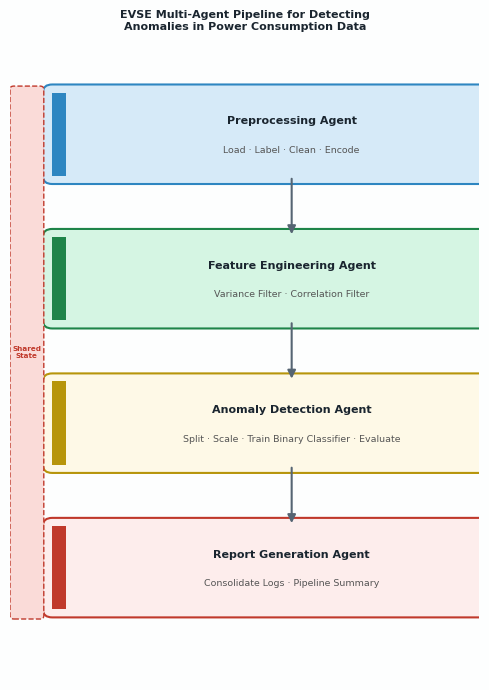

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(5, 7))
ax.set_xlim(0, 5)
ax.set_ylim(0, 8)
ax.axis("off")
fig.patch.set_facecolor("#FDFEFE")

agents = [
    ("Preprocessing Agent",       "Load · Label · Clean · Encode",      3.0, 6.8, "#D6EAF8", "#2E86C1"),
    ("Feature Engineering Agent", "Variance Filter · Correlation Filter", 3.0, 5.0, "#D5F5E3", "#1E8449"),
    ("Anomaly Detection Agent",   "Split · Scale · Train Binary Classifier · Evaluate",    3.0, 3.2, "#FEF9E7", "#B7950B"),
    ("Report Generation Agent",   "Consolidate Logs · Pipeline Summary", 3.0, 1.4, "#FDEDEC", "#C0392B"),
]

for idx, (title, subtitle, x, y, face, accent) in enumerate(agents):
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.45, y - 0.52), 4.7, 1.04,
        boxstyle="round,pad=0.1",
        facecolor=face, edgecolor=accent, linewidth=1.5, zorder=2
    ))
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.45, y - 0.52), 0.15, 1.04,
        boxstyle="square,pad=0.0",
        facecolor=accent, edgecolor="none", zorder=3
    ))
    ax.text(x, y + 0.16, title,
            ha="center", va="center",
            fontsize=8, fontweight="bold", color="#1A252F", zorder=4)
    ax.text(x, y - 0.2, subtitle,
            ha="center", va="center",
            fontsize=6.8, color="#555555", zorder=4)

# Arrows
for i in range(len(agents) - 1):
    y_start = agents[i][3]   - 0.52
    y_end   = agents[i+1][3] + 0.52
    ax.annotate("", xy=(3.0, y_end), xytext=(3.0, y_start),
                arrowprops=dict(arrowstyle="-|>", color="#566573",
                                lw=1.5, mutation_scale=12), zorder=2)

# Shared State sidebar
ax.add_patch(mpatches.FancyBboxPatch(
    (0.04, 0.8), 0.28, 6.56,
    boxstyle="round,pad=0.04",
    facecolor="#FADBD8", edgecolor="#C0392B",
    linewidth=1.0, linestyle="--", zorder=2
))
ax.text(0.18, 4.08, "Shared\nState",
        ha="center", va="center",
        fontsize=5.2, color="#C0392B", fontweight="bold")

ax.set_title(
    "EVSE Multi-Agent Pipeline for Detecting\nAnomalies in Power Consumption Data",
    fontsize=8, fontweight="bold", color="#1A252F", pad=6
)

plt.tight_layout()
plt.show()

## 1. Imports & Configuration

In [3]:
import os
import json
import textwrap
import warnings
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from tensorflow.keras.callbacks import EarlyStopping

from agno.agent import Agent
from agno.models.openai import OpenAIChat
from agno.tools import tool


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/Users/rasikasonar/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/rasikasonar/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
DATA_PATH = "Dataset_for_masters_thesis/CICEVSE2024_Dataset/Power Consumption/EVSE-B-PowerCombined.csv"

In [5]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

## 2. Shared data between the agents.

To share the databetween the agents, we would be making use of dataclasses. Model parameters, preprocessed dataframes, selected features, sequences will be shared among the agents using this dataclass

In [6]:
@dataclass
class SharedDomainData:
    raw_df:              Optional[pd.DataFrame] = None               # To store the raw dataframe
    preprocessed_df:     Optional[pd.DataFrame] = None               # To store the dataframe after preprocessing
    feature_df:          Optional[pd.DataFrame] = None               # To store the dataframe after feature engg

    # Each agent tools will write to it's specific log variables.
    preprocessing_log:   List[str] = field(default_factory=list)
    feature_log:         List[str] = field(default_factory=list)
    detection_log:       List[str] = field(default_factory=list)

    feature_cols:        List[str] = field(default_factory=list)     # To store selected columns after feature engg.

    # To store the train, test and validation dataset.
    X_train:             Optional[pd.DataFrame] = None
    X_val:               Optional[pd.DataFrame] = None
    X_test:              Optional[pd.DataFrame] = None
    y_train:             Optional[pd.Series]    = None
    y_val:               Optional[pd.Series]    = None
    y_test:              Optional[pd.Series]    = None

    # To store the train, test & val sequences which will be fed to LSTM classifier
    X_train_seq:         Optional[np.ndarray]   = None
    X_val_seq:           Optional[np.ndarray]   = None
    X_test_seq:          Optional[np.ndarray]   = None
    y_train_seq:         Optional[np.ndarray]   = None
    y_val_seq:           Optional[np.ndarray]   = None
    y_test_seq:          Optional[np.ndarray]   = None
    train_seq_end_index: Optional[np.ndarray]   = None
    val_seq_end_index:   Optional[np.ndarray]   = None
    test_seq_end_index:  Optional[np.ndarray]   = None
    sequence_length:     Optional[int]          = None
    y_pred:              Optional[np.ndarray]   = None
    scores:              Optional[np.ndarray]   = None

    training_history:    Optional[Dict[str, List[float]]] = None      # For storing training history of a model

    # To store the model, model parameters and output metrix
    scaler:              Optional[RobustScaler] = None
    model_name:          Optional[str]          = None
    model:               Optional[Any]          = None
    threshold:           Optional[float]        = None
    val_metrics:         Optional[Dict]         = None
    test_metrics:        Optional[Dict]         = None
    test_results_df:     Optional[pd.DataFrame] = None

    report:              Optional[str]          = None                 # To store the report of anomaly detection


In [7]:
state = SharedDomainData()

## 3. Tool Definitions

We will be defining the tools that agent will use in sequence to handle a specific task. 

### 3.1 Preprocessing Tools

In [8]:
# -----------------------------------------------------------------------------
# -------------Clean the data from filepath------------------------------------
# -----------------------------------------------------------------------------
@tool
def load_data(filepath: str) -> str:
    """
    Load the power consumption data from a file path

    Args:
        filepath: Path to the CSV file.

    Returns:
        Summary of loaded dataset.
    """
    df = pd.read_csv(filepath)
    state.raw_df = df.copy()
    state.preprocessing_log.append(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns.\n\n")
    state.preprocessing_log.append(f"Columns: {list(df.columns)}\n\n")
    state.preprocessing_log.append(f"Missing values:\n{df.isnull().sum().to_string()}")
    return f"Dataset loaded of shape {df.shape}"

In [9]:
# -----------------------------------------------------------------------------
# -------------Clean the data and perform cleanliness checks-------------------
# -----------------------------------------------------------------------------
@tool
def clean_and_validate() -> str:
    """
    - Checks if data has null values
    - Drop unnamed index columns.
    - Check if there are any duplicate rows
    - Validate that operational parameters of EVSE such as power, voltage, and current columns are non-negative.
    - Converts target column Label into binary(benign=0, attack=1).

    Returns:
        Summary of data cleaning and validation checks
    """

    df = state.raw_df.copy()

    # Drop unnamed index columns
    unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
    if unnamed:
        df.drop(columns=unnamed, inplace=True)
        state.preprocessing_log.append(f"Dropped unnamed columns: {unnamed}")
    else:
        state.preprocessing_log.append("No unnamed columns to drop")

    # Deduplicate
    before = len(df)
    df.drop_duplicates(inplace=True)
    dupes = before - len(df)
    state.preprocessing_log.append(f"Duplicate rows removed: {dupes}")

    # Validate that operational parameters of EVSE can not have negative values
    evse_operational_features = ["bus_voltage_V", "current_mA", "power_mW", "shunt_voltage"]
    for col in evse_operational_features:
        neg = (df[col] < 0).sum()
        state.preprocessing_log.append(f"Feature {col} has {neg} negative values (expected 0)")
    
    # Validate for Missing values
    null_counts = int(df.isnull().sum().sum())
    state.preprocessing_log.append(f"Missing values in dataset {null_counts}")

    # Changing target column into binary columns
    if "Label" in df.columns:
        df["Label"] = df["Label"].map({"benign": 0, "attack": 1})
        state.preprocessing_log.append(f"\nLabel distribution after target variable encoding:\n{df['Label'].value_counts().to_string()}")

    state.preprocessing_log.append("clean_and_validate: done")
    state.raw_df = df
    return f"Data cleaning checks completed. Shape after handling missing values {df.shape}"

In [10]:
# -----------------------------------------------------------------------------
# -------------Reconstruct the timestamp, add second interval------------------
# -----------------------------------------------------------------------------
@tool
def reconstruct_timestamps() -> str:
    """
    Reconstruct second-level timestamps from the minute-level 'time' column.

    The EVSE dataset captures one row per second however the values stored against time column contains only minute interval.
    This tool will
    1. Parses 'time' as datetime.
    2. Within each minute group, assigns a sequential 1-second offset.
    3. Stores the result as a new 'timestamp' column 

    Returns:
        Summary of timestamp reconstruction outcome.
    """
    df = state.raw_df.copy()

    df["time"] = pd.to_datetime(df["time"], format="%m/%d/%Y %H:%M", errors="coerce")
    df = df.reset_index(drop=True)

    # no minute bucket should have more than 60 rows
    counts = df.groupby("time").size()
    over = counts[counts > 60]
    if not over.empty:
        return (
            f"WARNING: {len(over)} minute(s) have >60 rows — "
            "second-level reconstruction may be inaccurate.\n"
            + over.head(5).to_string()
        )
    else:
        state.preprocessing_log.append("There are no rows having more than 60 records per minute")

    df["sec_offset"] = df.groupby("time").cumcount() + 1
    df["timestamp"]  = df["time"] + pd.to_timedelta(df["sec_offset"], unit="s")

    df = df.sort_values("timestamp").reset_index(drop=True)
    df.drop(columns=["sec_offset"], errors="ignore", inplace=True)

    state.preprocessed_df = df
    return "Preprocessing done on dataset"

### 3.2 Feature Engineering Tools

##### The baseline paper of the EVSECIC2024 dataset has stated clearly that the current drawn by EVSE's main board is significantly higher in anomalous scenarios. We will calculate the expected power demand by multiplying voltage and current and compare it with the actual power demand. The difference between expected and actual power can be an indicator for anomalous behaviour

In [11]:
# -----------------------------------------------------------------------------
# ----Derive expected power and calculate the difference with actual power-----
# -----------------------------------------------------------------------------
@tool
def derive_power_features() -> str:
    """
    Derive physics-based power features:
    - expected_power_mW  = bus_voltage_V × current_mA  (Ohm's law baseline)
    - power_residual     = actual − expected  (anomaly indicator)
    - power_residual_abs = |power_residual|
    - power_to_current_ratio and power_to_voltage_ratio (efficiency proxies)

    Returns:
        Feature summary statistics.
    """
    df = state.preprocessed_df.copy()

    # Expected power is a multiplication factor of voltage and current
    df["expected_power_mW"]       = df["bus_voltage_V"] * df["current_mA"]

    # Calculate the difference between expected and actual power drawn
    df["power_residual"]          = df["power_mW"] - df["expected_power_mW"]

    # Absolute of the expected and actual power difference
    df["power_residual_abs"]      = df["power_residual"].abs()
    
    # Calculate ratio of power with current and voltage
    df["power_to_current_ratio"]  = df["power_mW"] / (df["current_mA"] + 1e-6)
    df["power_to_voltage_ratio"]  = df["power_mW"] / (df["bus_voltage_V"] + 1e-6)

    new_cols = [
        "expected_power_mW", "power_residual", "power_residual_abs", "power_to_current_ratio", "power_to_voltage_ratio"
    ]
    state.preprocessed_df = df
    state.feature_log.append(f"derive_power_features: added {new_cols}")
    return f"Added {len(new_cols)} power features.\n" + df[new_cols].describe().to_string()

##### In the context of ev charging, anomalies often occure from a sudden increase in power and voltage demand. For every xth second interval, we will be calculating voltage, current and power demand for x-1st, x-2nd and x-5th interval and storing it at xth row level. These features will provide correlation between the target variable which will be helpful for our agentic framework to identify the relevant features that contribute to anomalous behaviour

In [12]:
# -----------------------------------------------------------------------------
# ----Derive x-1, x-2 and x-5 lag features for time, voltage and power---------
# -----------------------------------------------------------------------------
@tool
def derive_lag_and_diff_features() -> str:
    """
    For each signal in [shunt_voltage, bus_voltage_V, current_mA,
    power_mW, power_residual], calculate
    - <signal>_lag_1, _lag_2, _lag_5
    - <signal>_diff_1, _diff_2  (current minus lag)
    - <signal>_abs_diff_1       (absolute first difference)

    Returns:
        Number of lag/diff features created.
    """
    df = state.preprocessed_df.copy()
    
    signals = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "power_residual"]
    added = []

    for col in signals:
        if col not in df.columns:
            continue
        for lag in [1, 2, 5]:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
            added.append(f"{col}_lag_{lag}")

        for diff in [1, 2]:
            df[f"{col}_diff_{diff}"]     = df[col] - df[f"{col}_lag_{diff}"]
            df[f"{col}_abs_diff_{diff}"] = df[f"{col}_diff_{diff}"].abs()
            added += [f"{col}_diff_{diff}", f"{col}_abs_diff_{diff}"]

    state.preprocessed_df = df
    state.feature_log.append(f"derive_lag_and_diff_features: added {len(added)} features")
    return f"Added {len(added)} lag/diff features. Examples: {added[:6]}"

In [13]:
# -----------------------------------------------------------------------------
# -----------Derive rolling window features for key signal parameters----------
# -----------------------------------------------------------------------------
@tool
def derive_rolling_features() -> str:
    """
    Derive rolling-window statistics (mean, std, min, max) for key signals
    over windows of 5, 10, and 30 seconds.

    Returns:
        Number of rolling features created.
    """
    df = state.preprocessed_df.copy()
    signals = ["bus_voltage_V", "current_mA", "power_mW", "power_residual"]
    windows = [5, 10, 30]
    stats   = ["mean", "std", "min", "max"]
    added   = []
    added_feature = 0

    for col in signals:
        for w in windows:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"] = df[col].rolling(window=w, min_periods=1).std()
            df[f"{col}_roll_min_{w}"] = df[col].rolling(window=w, min_periods=1).min()
            df[f"{col}_roll_max_{w}"] = df[col].rolling(window=w, min_periods=1).max()
            added_feature = added_feature+1

    state.preprocessed_df = df
    state.feature_log.append(f"derive_rolling_features: added {added_feature} features")
    return f"Added {added_feature} rolling features across windows {windows}."

##### There are four non numeric columns in the dataset: State, interface, Attack & Attack-Group. We will use only State & Interface for one-hot encoding. Attack and Attack-Group describe the type of attack performed while capturing an attack scenario; the binary classifier learns directly from the Label column, so these extra categorical descriptors are not required as features and will be dropped later in finalise_feature_set.


In [14]:
# -----------------------------------------------------------------------------
# -----------Encode categorical columns State & Interface----------------------
# -----------------------------------------------------------------------------
@tool
def encode_categorical_columns() -> str:
    """
    Converts categorical columns into numerical format using one-hot encoding.

    Returns:
        Summary of categorical columns converted into numerical format
    """
    df = state.preprocessed_df.copy()
    
    categorical_columns = ["State", "interface"]

    log = []
    log.append("Unique values for non numerical columns")

    for col in categorical_columns:
        unique_vals = df[col].dropna().unique()
        log.append(f"{col}: Unique values ({len(unique_vals)}): {list(unique_vals)}")

    log.append("Applying 1-hot encoding")

    existing_cols = [col for col in categorical_columns if col in df.columns]
    df = pd.get_dummies(df, columns=existing_cols, dtype=int)

    log.append(f"Encoding complete. New shape: {df.shape}")

    state.preprocessed_df = df
    state.feature_log.append(
        f"Encoded categorical columns into numerical: {existing_cols}"
    )
    return f"Encoded categorical columns into numerical: {existing_cols}"

##### Now we will divide the columns into the feature set that will be further used for scaling and model training. We will be excluding some of the categorical features which don't have any significance anymore.

In [15]:
# -----------------------------------------------------------------------------
# -------Finalize the feature columns to be used further for training----------
# -----------------------------------------------------------------------------
@tool
def finalise_feature_set() -> str:
    """
    Drop NaN rows introduced by lags, separate features from metadata columns,
    and store the final feature matrix in the pipeline state.

    Returns:
        Final dataset shape
    """
    df = state.preprocessed_df.copy()
    df = df.dropna().reset_index(drop=True)

    exclude = {"time", "timestamp", "Label", "Attack", "Attack-Group", "State", "interface"}
    feature_cols = [c for c in df.columns if c not in exclude]

    non_numeric = df[feature_cols].select_dtypes(include="object").columns.tolist()
    
    state.feature_log.append(f"Non numeric columns left after feature engineering: {non_numeric}")
    
    if non_numeric:
        df.drop(columns=non_numeric, inplace=True)
        feature_cols = [c for c in feature_cols if c not in non_numeric]

    state.feature_df   = df
    state.feature_cols = feature_cols
    state.feature_log.append(f"finalise_feature_set: {len(feature_cols)} features, {len(df)} rows")
    state.feature_log.append(f"feature columns: {feature_cols}")
    return (f"Feature Engineering completed. Finalise_feature_set: {len(feature_cols)} features, {len(df)} rows")

### 3.3 Detection Tools

We use a stratified shuffle split on `Attack-Group` column, which distributes every attack type across train, validation and test. Inside each split we re-sort by the original row index so that the temporal order of the data remains as it is.

In [16]:
# -----------------------------------------------------------------------------
# ------Stratified shuffle split by Attack-Group (70 / 15 / 15)----------------
# -----------------------------------------------------------------------------
@tool
def split_and_scale(
    train_ratio: float = 0.70,
    val_ratio:   float = 0.15,
    test_ratio:  float = 0.15,
    random_state: int = 42,
) -> str:
    """
    Stratified shuffle split that guarantees every Attack-Group (including the
    benign group) is proportionally represented in train, validation and test.
    """
    df   = state.feature_df
    cols = state.feature_cols

    X = df[cols]
    y = df["Label"]

    if "Attack-Group" in df.columns:
        strat = df["Attack-Group"].astype(str).fillna("Benign")
        strat_name = "Attack-Group"
    elif "Attack" in df.columns:
        strat = df["Attack"].astype(str).fillna("Benign")
        strat_name = "Attack"
    else:
        strat = y.astype(str)
        strat_name = "Label"

    # Merge any stratum that has < 3 samples into an 'other' bucket so
    # StratifiedShuffleSplit is always feasible.
    counts = strat.value_counts()
    rare   = counts[counts < 3].index.tolist()
    if rare:
        strat = strat.where(~strat.isin(rare), other="__rare__")

    # ── First split: train vs (val + test) ───────────────────────────────────
    sss1 = StratifiedShuffleSplit(
        n_splits=1, test_size=val_ratio + test_ratio, random_state=random_state
    )
    idx_train, idx_rest = next(sss1.split(X, strat))

    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_rest,  y_rest  = X.iloc[idx_rest],  y.iloc[idx_rest]
    strat_rest = strat.iloc[idx_rest]

    # ── Second split: val vs test inside the held-out portion ────────────────
    rel_test_size = test_ratio / (val_ratio + test_ratio)
    sss2 = StratifiedShuffleSplit(
        n_splits=1, test_size=rel_test_size, random_state=random_state
    )
    idx_val_rel, idx_test_rel = next(sss2.split(X_rest, strat_rest))

    X_val,  y_val  = X_rest.iloc[idx_val_rel],  y_rest.iloc[idx_val_rel]
    X_test, y_test = X_rest.iloc[idx_test_rel], y_rest.iloc[idx_test_rel]

    # ── Re-sort each split by its original index so sequence building
    #    preserves local temporal order inside the split. ────────────────────
    def _sort_by_index(Xs, ys):
        order = Xs.index.argsort()
        return Xs.iloc[order], ys.iloc[order]

    X_train, y_train = _sort_by_index(X_train, y_train)
    X_val,   y_val   = _sort_by_index(X_val,   y_val)
    X_test,  y_test  = _sort_by_index(X_test,  y_test)

    # ── Fit scaler on train only, then transform the other splits ───────────
    scaler = RobustScaler()
    X_train_sc = pd.DataFrame(
        scaler.fit_transform(X_train), columns=cols, index=X_train.index
    )
    X_val_sc = pd.DataFrame(
        scaler.transform(X_val), columns=cols, index=X_val.index
    )
    X_test_sc = pd.DataFrame(
        scaler.transform(X_test), columns=cols, index=X_test.index
    )

    state.X_train = X_train_sc; state.y_train = y_train
    state.X_val   = X_val_sc;   state.y_val   = y_val
    state.X_test  = X_test_sc;  state.y_test  = y_test
    state.scaler  = scaler

    def dist(s):
        vc = s.value_counts().to_dict()
        return {int(k): f"{v} ({v/len(s)*100:.1f}%)" for k, v in vc.items()}

    def group_dist(idx_of_split):
        sub = df.loc[idx_of_split, strat_name].astype(str)
        vc  = sub.value_counts().to_dict()
        return {k: int(v) for k, v in vc.items()}

    state.detection_log.append(f"Split strategy : stratified shuffle by {strat_name}")
    state.detection_log.append(
        f"Train : {len(X_train)} rows | Label dist {dist(y_train)}"
    )
    state.detection_log.append(
        f"Val   : {len(X_val)} rows | Label dist {dist(y_val)}"
    )
    state.detection_log.append(
        f"Test  : {len(X_test)} rows | Label dist {dist(y_test)}"
    )
    state.detection_log.append(
        f"Train {strat_name} distribution: {group_dist(X_train.index)}"
    )
    state.detection_log.append(
        f"Val   {strat_name} distribution: {group_dist(X_val.index)}"
    )
    state.detection_log.append(
        f"Test  {strat_name} distribution: {group_dist(X_test.index)}"
    )
    state.detection_log.append(
        "RobustScaler fit on train only; val/test transformed."
    )
    return (
        f"Stratified split by {strat_name} done. "
        f"Train/Val/Test sizes: {len(X_train)}/{len(X_val)}/{len(X_test)}"
    )


In [17]:
SEQUENCE_LENGTH = 30

# -----------------------------------------------------------------------------
# ---Create sequences from a dataframe to feed into the LSTM classifier -------
# -----------------------------------------------------------------------------
def _create_sequences_from_df(
    X_df: pd.DataFrame,
    y_sr: Optional[pd.Series] = None,
    seq_length: int = SEQUENCE_LENGTH,
):
    """
    Create fixed-length sliding-window sequences from a feature dataframe.
    The label assigned to each sequence is the label of the last row in the
    window (i.e. the sequence is used to predict the state at its endpoint).
    """
    X_values = X_df.values
    y_values = y_sr.values if y_sr is not None else None
    indices  = X_df.index.to_numpy()

    X_seq, y_seq, end_idx = [], [], []

    for i in range(len(X_values) - seq_length + 1):
        X_seq.append(X_values[i:i + seq_length])
        end_idx.append(indices[i + seq_length - 1])
        if y_values is not None:
            y_seq.append(y_values[i + seq_length - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq) if y_sr is not None else None
    end_idx = np.array(end_idx)

    return X_seq, y_seq, end_idx


In [18]:
# -----------------------------------------------------------------------------
# ---------------Train LSTM Binary Classifier on benign + attack sequences ----
# -----------------------------------------------------------------------------
@tool
def train_lstm_binary_classifier(
    epochs: int = 50,
    batch_size: int = 64,
    hidden_dim: int = 64,
    latent_dim: int = 32,
    learning_rate: float = 1e-4,
    l2_reg: float = 1e-5,
    random_state: int = 42,
) -> str:
    """
    Train a supervised LSTM binary classifier on sequences built from the
    training split. The training split contains BOTH benign (Label=0) and
    attack (Label=1) rows.

    Architecture:
        Input(SEQUENCE_LENGTH, n_features)
          - LSTM(hidden_dim, return_sequences=True, L2)  + Dropout
          - LSTM(latent_dim, return_sequences=False, L2) + Dropout
          - Dense(16, relu, L2)
          - Dense(1, sigmoid)

    """
    tf.keras.utils.set_random_seed(random_state)
    seq_length = SEQUENCE_LENGTH

    # ── Build sequences from the FULL (benign + attack) training split ─────
    X_train_seq, y_train_seq, train_end_idx = _create_sequences_from_df(
        state.X_train, state.y_train, seq_length
    )
    X_val_seq, y_val_seq, val_end_idx = _create_sequences_from_df(
        state.X_val, state.y_val, seq_length
    )
    X_test_seq, y_test_seq, test_end_idx = _create_sequences_from_df(
        state.X_test, state.y_test, seq_length
    )

    if len(X_train_seq) == 0:
        raise ValueError(
            f"Not enough training rows to build sequences of length {seq_length}."
        )

    classes = np.unique(y_train_seq)
    if len(classes) < 2:
        raise ValueError(
            f"Training sequences contain only one class {classes}. "
            f"A supervised classifier needs both benign and attack examples."
        )

    n_features = X_train_seq.shape[2]
    reg = l2(l2_reg)

    # ── Define the binary classifier ────────────────────────────────────────
    inputs = Input(shape=(seq_length, n_features))
    x = LSTM(
        hidden_dim,
        activation="tanh",
        return_sequences=True,
        kernel_regularizer=reg,
        recurrent_regularizer=reg,
    )(inputs)
    x = Dropout(0.3)(x)
    x = LSTM(
        latent_dim,
        activation="tanh",
        return_sequences=False,
        dropout=0.2,
        kernel_regularizer=reg,
        recurrent_regularizer=reg,
    )(x)
    x = Dropout(0.3)(x)
    x = Dense(16, activation="relu", kernel_regularizer=reg)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    # ── Monitor val_auc: threshold-free metric, stable under class imbalance ─
    early_stop = EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=8,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq.astype(np.float32),
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_seq, y_val_seq.astype(np.float32)),
        callbacks=[early_stop],
        verbose=0,
    )

    # ── Persist model + sequences to shared state ───────────────────────────
    state.model               = model
    state.model_name          = "LSTMBinaryClassifier"
    state.sequence_length     = seq_length
    state.X_train_seq         = X_train_seq
    state.X_val_seq           = X_val_seq
    state.X_test_seq          = X_test_seq
    state.y_train_seq         = y_train_seq
    state.y_val_seq           = y_val_seq
    state.y_test_seq          = y_test_seq
    state.train_seq_end_index = train_end_idx
    state.val_seq_end_index   = val_end_idx
    state.test_seq_end_index  = test_end_idx
    state.training_history    = history.history

    train_dist = {int(c): int((y_train_seq == c).sum()) for c in classes}
    val_dist   = {int(c): int((y_val_seq   == c).sum()) for c in np.unique(y_val_seq)}
    test_dist  = {int(c): int((y_test_seq  == c).sum()) for c in np.unique(y_test_seq)}

    state.detection_log.append(
        f"Sequence length (pinned): {seq_length}"
    )
    state.detection_log.append(
        f"LSTM Binary Classifier trained on benign+attack sequences: {X_train_seq.shape}"
    )
    state.detection_log.append(
        f"Training   sequence label distribution: {train_dist}"
    )
    state.detection_log.append(
        f"Validation sequence label distribution: {val_dist}"
    )
    state.detection_log.append(
        f"Test       sequence label distribution: {test_dist}"
    )
    state.detection_log.append(
        f"class_weight: disabled (attacks are the majority class)"
    )
    state.detection_log.append(
        f"Optimiser Adam(lr={learning_rate}), L2={l2_reg}, dropout=0.3"
    )
    state.detection_log.append(
        f"EarlyStopping on val_auc, patience=8, restore_best_weights=True"
    )

    return "LSTM Binary Classifier trained on benign + attack sequences."


In [19]:
# -----------------------------------------------------------------------------
# ---------Log training history such as epochs, val loss, val auc--------------
# -----------------------------------------------------------------------------
@tool
def log_training_history() -> str:
    """Summarise training history of the LSTM binary classifier."""
    if not state.training_history:
        return "No training history available."

    hist          = state.training_history
    loss          = hist["loss"]
    val_loss      = hist["val_loss"]
    last_loss     = loss[-1]
    last_val_loss = val_loss[-1]

    if "val_auc" in hist and hist["val_auc"]:
        best_epoch = int(np.argmax(hist["val_auc"])) + 1
        best_src   = f"highest val_auc={max(hist['val_auc']):.4f}"
    else:
        best_epoch = int(np.argmin(val_loss)) + 1
        best_src   = f"lowest val_loss={min(val_loss):.6f}"

    state.detection_log.append(f"Training epochs: {len(loss)}")
    state.detection_log.append(f"Final train loss: {last_loss:.6f}")
    state.detection_log.append(f"Final val loss:   {last_val_loss:.6f}")
    state.detection_log.append(f"Best epoch ({best_src}): {best_epoch}")

    for key in ("val_accuracy", "val_precision", "val_recall", "val_auc"):
        if key in hist and hist[key]:
            state.detection_log.append(f"Final {key}: {hist[key][-1]:.4f}")

    return "Training history captured"


In [20]:
# -----------------------------------------------------------------------------
# ------------Produce per-sequence attack probabilities from the classifier----
# -----------------------------------------------------------------------------
def _predict_probabilities(model, X_seq: np.ndarray) -> np.ndarray:
    """Return the model's predicted probability of class 1 (attack) per sequence."""
    probs = model.predict(X_seq, verbose=0)
    return probs.ravel()


In [21]:
# -----------------------------------------------------------------------------
# ----Tune the decision threshold of the classifier on the validation set ------
# -----------------------------------------------------------------------------
@tool
def optimise_threshold(optimise_for: str = "f1") -> str:
    """
    Find the probability threshold that maximises a chosen metric on the
    validation set. For the LSTM binary classifier the anomaly score is the
    sigmoid probability of class 1 (attack); higher means more likely attack.

    Args:
        optimise_for: Metric to maximise — 'f1', 'recall', or 'precision'
                      (default 'f1').

    Returns:
        Chosen threshold and corresponding validation metrics.
    """
    scores = _predict_probabilities(state.model, state.X_val_seq)
    y_val  = state.y_val_seq

    prec, rec, threshs = precision_recall_curve(y_val, scores)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)

    if len(threshs) == 0:
        best_thresh = 0.5
        state.detection_log.append(
            f"No thresholds returned from precision_recall_curve — defaulting to {best_thresh}"
        )
    else:
        if optimise_for == "f1":
            idx = int(np.argmax(f1s[:-1]))
        elif optimise_for == "recall":
            idx = int(np.argmax(rec[:-1]))
        elif optimise_for == "precision":
            idx = int(np.argmax(prec[:-1]))
        else:
            idx = int(np.argmax(f1s[:-1]))
        best_thresh = float(threshs[idx])
        state.detection_log.append(
            f"Predicted probability threshold {best_thresh:.6f} optimised for {optimise_for}"
        )

    state.threshold = best_thresh

    y_pred_val = (scores >= best_thresh).astype(int)
    metrics = {
        "threshold":  round(best_thresh, 6),
        "precision":  round(precision_score(y_val, y_pred_val, zero_division=0), 4),
        "recall":     round(recall_score(y_val,    y_pred_val, zero_division=0), 4),
        "f1":         round(f1_score(y_val,        y_pred_val, zero_division=0), 4),
    }
    state.val_metrics = metrics
    state.detection_log.append(f"Validation threshold optimisation completed. Val metrics: {metrics}")
    return "Optimised probability threshold chosen on the validation set."


In [22]:
# -----------------------------------------------------------------------------
# --------------------------Evaluate on test dataset---------------------------
# -----------------------------------------------------------------------------
@tool
def evaluate_on_test_set() -> str:
    """
    Apply the optimised probability threshold to the held-out test set and
    compute final evaluation metrics (precision, recall, F1, ROC-AUC, PR-AUC).
    """
    scores = _predict_probabilities(state.model, state.X_test_seq)
    state.scores = scores

    y_pred = (scores >= state.threshold).astype(int)
    state.y_pred = y_pred
    y_true = state.y_test_seq

    metrics = {
        "precision":  round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":     round(recall_score(y_true,    y_pred, zero_division=0), 4),
        "f1":         round(f1_score(y_true,        y_pred, zero_division=0), 4),
        "roc_auc":    round(roc_auc_score(y_true, scores),              4),
        "pr_auc":     round(average_precision_score(y_true, scores),    4),
    }
    state.test_metrics = metrics

    results_df = state.X_test.loc[state.test_seq_end_index].copy()
    results_df["attack_probability"] = scores
    results_df["predicted"]          = y_pred
    results_df["actual"]             = y_true
    results_df["correct"]            = (results_df["predicted"] == results_df["actual"])
    state.test_results_df = results_df

    state.detection_log.append(f"Evaluation completed on test dataset. Test metrics: {metrics}")
    return "Evaluation completed on test dataset. Detection agent can proceed to generate report"


### 3.4 Reporting Tool

In [23]:
# --------------------------------------------------------------
# ------------Generate report from all agent logs---------------
# --------------------------------------------------------------
@tool
def generate_anomaly_report() -> str:
    """
    Compile all pipeline results (preprocessing log, feature log,
    model details, validation metrics, test metrics, per-class
    classification report) into a structured plain-text report.

    Returns:
        Report generation status.
    """
    val  = state.val_metrics  or {}
    test = state.test_metrics or {}

    if state.test_results_df is not None:
        flagged_count = int((state.test_results_df["predicted"] == 1).sum())
    else:
        flagged_count = "N/A"

    # Per-class classification_report on the test set
    if state.y_test_seq is not None and state.y_pred is not None:
        cls_report = classification_report(
            state.y_test_seq,
            state.y_pred,
            target_names=["Benign", "Attack"],
            digits=4,
            zero_division=0,
        )
        cm = confusion_matrix(state.y_test_seq, state.y_pred)
        cm_str = (
            f"                 Predicted\n"
            f"                 Benign   Attack\n"
            f"Actual Benign   {cm[0,0]:>7}  {cm[0,1]:>7}\n"
            f"Actual Attack   {cm[1,0]:>7}  {cm[1,1]:>7}"
        )
    else:
        cls_report = "Classification report unavailable (no predictions)."
        cm_str     = "Confusion matrix unavailable (no predictions)."

    report = textwrap.dedent(f"""\
    ╔══════════════════════════════════════════════════════════╗
    ║       EVSE Anomaly Detection — Pipeline Report          ║
    ╚══════════════════════════════════════════════════════════╝

    MODEL USED: {state.model_name}
    DECISION THRESHOLD (probability of attack): {state.threshold}
    SEQUENCE LENGTH (pinned): {state.sequence_length}

    ── PREPROCESSING LOG ──────────────────────────────────────
    {chr(10).join(state.preprocessing_log)}

    ── FEATURE ENGINEERING LOG ────────────────────────────────
    {chr(10).join(state.feature_log)}

    ── DETECTION LOG ──────────────────────────────────────────
    {chr(10).join(state.detection_log)}

    ── VALIDATION METRICS ─────────────────────────────────────
    Precision : {val.get('precision', 'N/A')}
    Recall    : {val.get('recall',    'N/A')}
    F1        : {val.get('f1',        'N/A')}

    ── TEST METRICS ───────────────────────────────────────────
    Precision : {test.get('precision', 'N/A')}
    Recall    : {test.get('recall',    'N/A')}
    F1        : {test.get('f1',        'N/A')}
    ROC-AUC   : {test.get('roc_auc',  'N/A')}
    PR-AUC    : {test.get('pr_auc',   'N/A')}

    ── PER-CLASS CLASSIFICATION REPORT (TEST) ─────────────────
    {cls_report}

    ── CONFUSION MATRIX (TEST) ────────────────────────────────
    {cm_str}

    ── FLAGGED EVENTS (test set) ──────────────────────────────
    Total anomalies flagged: {flagged_count}

    """)

    state.report = report
    return "Report generation successful"


## 4. Agent Definitions

We will be defining the Agents, their definitions and giving instructions to execute tools.

In [24]:
# We will be using OpenAI model
model = OpenAIChat(id="gpt-4o-mini", api_key=OPENAI_API_KEY, temperature=0.1)

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Agent 1 — Preprocessing Agent
# Responsibility: load data file, clean and validate for quality check, reconstruct timestamp column
# ─────────────────────────────────────────────────────────────────────────────
preprocessing_agent = Agent(
    name="PreprocessingAgent",
    model=model,
    tools=[
        load_data,
        clean_and_validate,
        reconstruct_timestamps
    ],
    instructions=[
        "You are a data preprocessing specialist for EV charging station (EVSE) sensor data.",
        "Your job is to load raw power consumption CSV data ",
        "Always execute tools in this order: load_data → clean_and_validate → reconstruct_timestamps.",
        "Report any data quality issues discovered during cleaning.",
        "Do not skip any tool — each one is required for the pipeline to succeed."
    ],
    markdown=False,
)

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Agent 2 — Feature Engineering Agent
# Responsibility: derive physics based features, lag and rolling features, 
#.                encode non numeric columns and finalize feature set
# ─────────────────────────────────────────────────────────────────────────────
feature_agent = Agent(
    name="FeatureEngineeringAgent",
    model=model,
    tools=[
        derive_power_features,
        derive_lag_and_diff_features,
        derive_rolling_features,
        encode_categorical_columns,
        finalise_feature_set,
    ],
    instructions=[
        "You are a time-series feature engineering specialist that works with time series data representing power consumption of an EVSE",
        "Your goal is to enrich the preprocessed dataset with features that best represent the relationship to anomaly behaviour",
        "Call all five tools in order:"
        "  1. derive_power_features",
        "  2. derive_lag_and_diff_features",
        "  3. derive_rolling_features",
        "  4. encode_categorical_columns",
        "  5. finalise_feature_set",
        "Report how many features were created in each step.",
        "Report any issues occurred during tool execution",
        "Do not skip any tool — each one is required for the pipeline to succeed."
    ],
    markdown=False,
)

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Agent 3 — Detection Agent
# Responsibility: scale data (stratified split), train LSTM binary classifier
#                 on benign+attack sequences, tune the decision threshold,
#                 evaluate on test.
# ─────────────────────────────────────────────────────────────────────────────
detection_agent = Agent(
    name="DetectionAgent",
    model=model,
    tools=[
        split_and_scale,
        train_lstm_binary_classifier,
        log_training_history,
        optimise_threshold,
        evaluate_on_test_set,
    ],
    instructions=[
        "You are an anomaly detection specialist for EVSE power consumption data.",
        "Your goal is to detect anomalies in EV charging station data using a supervised LSTM Binary Classifier.",
        "The classifier is trained on sequences labelled as benign (0) or attack (1).",
        "Sequence length is fixed at the module constant SEQUENCE_LENGTH (=30) and is NOT a tool argument. Do not pass a seq_length.",
        "Call all five tools in order with their DEFAULT arguments unless a problem occurs:",
        "1. split_and_scale",
        "2. train_lstm_binary_classifier",
        "3. log_training_history",
        "4. optimise_threshold",
        "5. evaluate_on_test_set",
        "Report any issues that occur during tool execution.",
        "Do not skip any tool — each one is required for the pipeline to succeed.",
    ],
    markdown=False,
)


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Agent 4 — Reporting Agent
# Responsibility: Summarize the report of anomaly detection model using log variables of all agents
# ─────────────────────────────────────────────────────────────────────────────
reporting_agent = Agent(
    name="ReportingAgent",
    model=model,
    tools=[generate_anomaly_report],
    instructions=[
        "You are a reporting who generates reports of anomaly detection",
        "Call generate_anomaly_report to compile all pipeline results."
    ],
    markdown=False,
)


## 5. Run the Pipeline

Now we will be invoking each agent in sequence by providing appropriate prompts

### 5.1 — PreprocessingAgent

In [29]:
print("=" * 65)
print("STEP 1 — PreprocessingAgent")
print("=" * 65)

preprocessing_agent.print_response(
    f"Load and preprocess the EVSE datasest located at '{DATA_PATH}'. "
    "Reconstruct second-level timestamps and validate data quality."
)

STEP 1 — PreprocessingAgent


Output()

### 5.2 — FeatureEngineeringAgent

In [30]:
print("=" * 65)
print("STEP 2 — FeatureEngineeringAgent")
print("=" * 65)

feature_agent.print_response(
    "Engineer features from the preprocessed EVSE data. "
    "Derive power residuals, lag/diff features, and rolling statistics. "
    "Then finalise the feature set by removing NaNs."
)

STEP 2 — FeatureEngineeringAgent


Output()

### 5.3 — DetectionAgent

In [31]:
print("=" * 65)
print("STEP 3 — DetectionAgent")
print("=" * 65)

detection_agent.print_response(
    "Execute the detection pipeline. "
    "Use split_and_scale to produce a stratified train/val/test split by Attack-Group. "
    "Train the LSTM Binary Classifier using its default arguments — do not pass any "
    "sequence length; the sequence length is pinned at the module constant SEQUENCE_LENGTH=30. "
    "Optimise the probability threshold for F1 on the validation set. "
    "Evaluate on the test set and report precision, recall, F1, ROC-AUC, and PR-AUC."
)


STEP 3 — DetectionAgent


Output()

WARNING:absl:At this time, the v2.11+ optimizer `tf.keras.optimizers.Adam` runs slowly on M1/M2 Macs, please use 
the legacy Keras optimizer instead, located at `tf.keras.optimizers.legacy.Adam`.

### 5.4 — ReportingAgent

In [32]:
print("=" * 65)
print("STEP 4 — ReportingAgent")
print("=" * 65)

reporting_agent.print_response(
    "Generate the full anomaly detection report for the EVSE pipeline. "
)

STEP 4 — ReportingAgent


Output()

---
## 6. Inspect Results Programmatically

In [33]:
# ── Print final report ────────────────────────────────────────────────────────
if state.report:
    print(state.report)

    ╔══════════════════════════════════════════════════════════╗
    ║       EVSE Anomaly Detection — Pipeline Report          ║
    ╚══════════════════════════════════════════════════════════╝

    MODEL USED: LSTMBinaryClassifier
    DECISION THRESHOLD (probability of attack): 0.8192347884178162
    SEQUENCE LENGTH (pinned): 30

    ── PREPROCESSING LOG ──────────────────────────────────────
    Loaded 115298 rows × 10 columns.


Columns: ['time', 'shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'State', 'Attack', 'Attack-Group', 'Label', 'interface']


Missing values:
time             0
shunt_voltage    0
bus_voltage_V    0
current_mA       0
power_mW         0
State            0
Attack           0
Attack-Group     0
Label            0
interface        0
No unnamed columns to drop
Duplicate rows removed: 1100
Feature bus_voltage_V has 0 negative values (expected 0)
Feature current_mA has 0 negative values (expected 0)
Feature power_mW has 0 negative values (expected 0)
Fe

In [34]:
open("Anomaly_Detection_Power_Consumption_Report.txt", "w").write(str(state.report))

6803

## Loss Curve

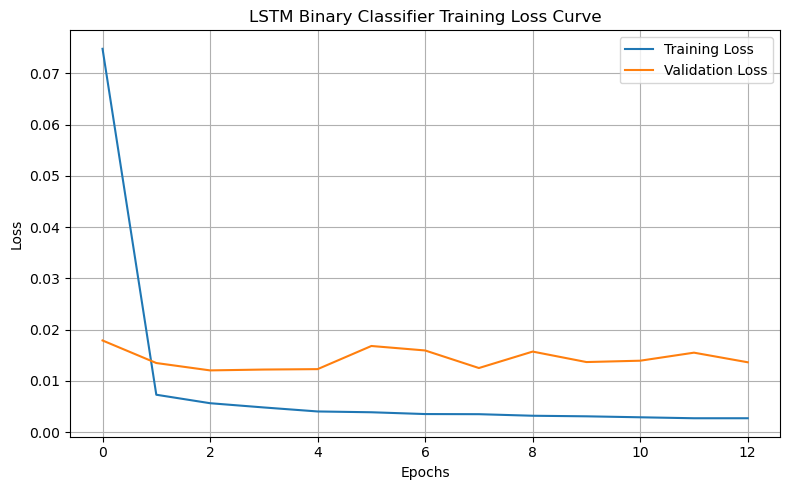

In [35]:
plt.figure(figsize=(8, 5))
loss = state.training_history['loss']
val_loss = state.training_history["val_loss"]
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Binary Classifier Training Loss Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Confusion Matrix

In [36]:
cm = confusion_matrix(state.y_test_seq, state.y_pred)
print(cm)

[[ 2134    11]
 [   19 14936]]


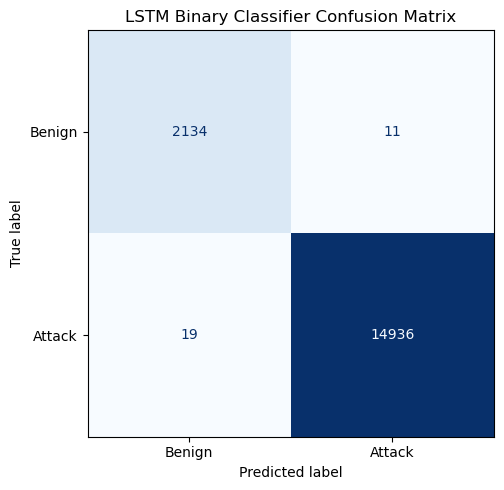

In [37]:
cm = confusion_matrix(state.y_test_seq, state.y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("LSTM Binary Classifier Confusion Matrix")
plt.tight_layout()
plt.show()


## ROC cuve

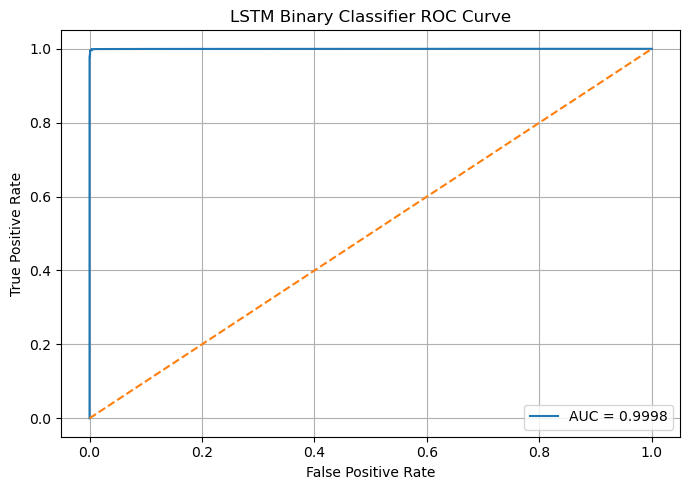

In [38]:
fpr, tpr, _ = roc_curve(state.y_test_seq, state.scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM Binary Classifier ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


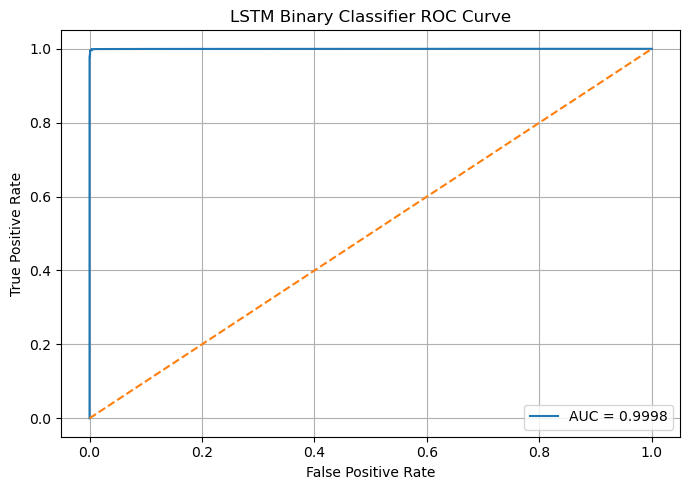

In [39]:
fpr, tpr, _ = roc_curve(state.y_test_seq, state.scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM Binary Classifier ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


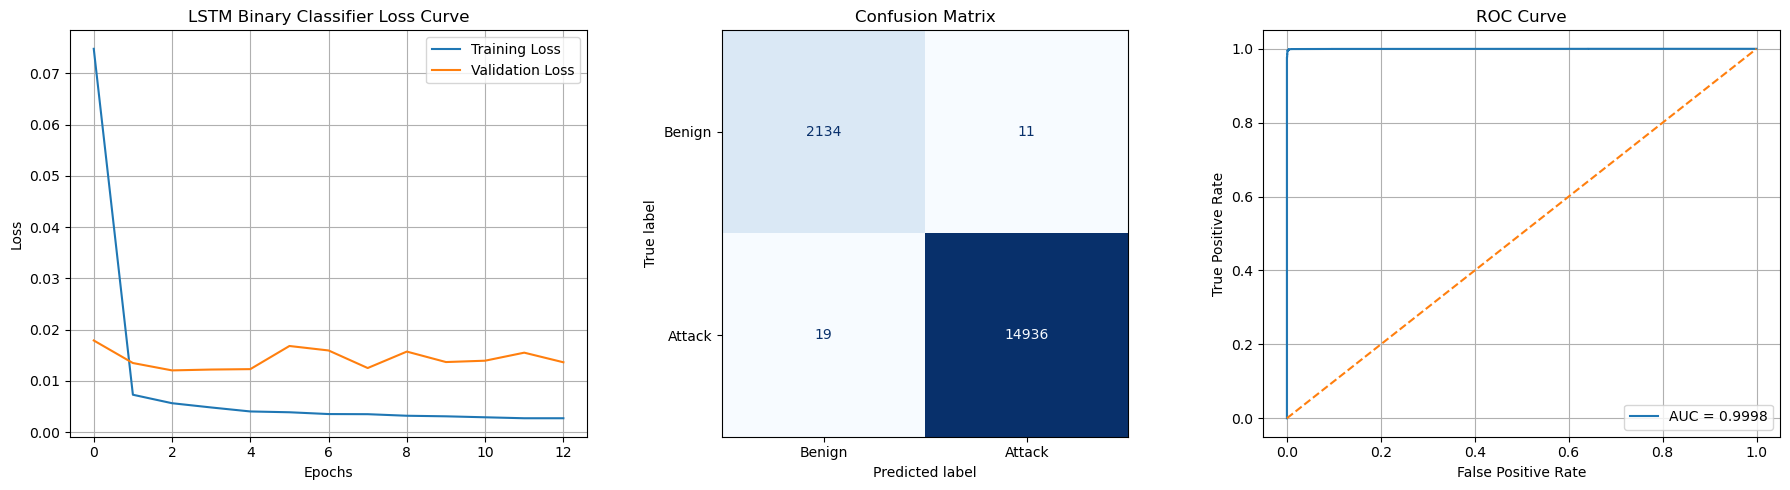

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

## Plot Loss curve
loss = state.training_history['loss']
val_loss = state.training_history["val_loss"]
axes[0].plot(loss, label='Training Loss')
axes[0].plot(val_loss, label='Validation Loss')
axes[0].set_title('LSTM Binary Classifier Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

## Plot Confusion Matrix
cm = confusion_matrix(state.y_test_seq, state.y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix')

## ROC curve
fpr, tpr, _ = roc_curve(state.y_test_seq, state.scores)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[2].plot([0, 1], [0, 1], linestyle='--')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')
axes[2].grid(True)

plt.tight_layout()
plt.show()
